In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [4]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDataset shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0

Dataset shape: (200, 5)


In [6]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

X = df[features]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [7]:
X.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)

X_scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [9]:
print("Means:")
print(X_scaled_df.mean())

print("\nStandard deviations:")
print(X_scaled_df.std())

Means:
Age                      -1.021405e-16
Annual Income (k$)       -2.131628e-16
Spending Score (1-100)   -1.465494e-16
dtype: float64

Standard deviations:
Age                       1.002509
Annual Income (k$)        1.002509
Spending Score (1-100)    1.002509
dtype: float64


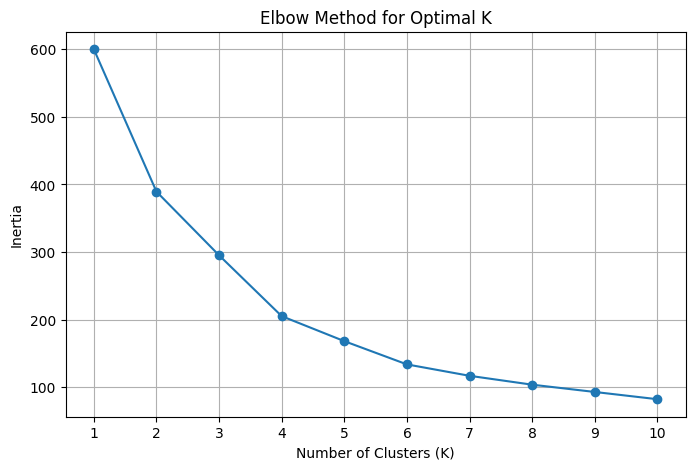

In [10]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [11]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


In [12]:
print("K-Means Cluster Distribution:")
print(df['KMeans_Cluster'].value_counts().sort_index())

K-Means Cluster Distribution:
KMeans_Cluster
0    65
1    40
2    57
3    38
Name: count, dtype: int64


In [13]:
silhouette_kmeans = silhouette_score(X_scaled, kmeans_labels)

print("K-Means Silhouette Score:", silhouette_kmeans)

K-Means Silhouette Score: 0.4039582785148566


In [14]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original number of features:", X_scaled.shape[1])
print("Reduced number of features:", X_pca.shape[1])

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal explained variance:",
      pca.explained_variance_ratio_.sum())

Original number of features: 3
Reduced number of features: 2

Explained variance ratio:
[0.44266167 0.33308378]

Total explained variance: 0.7757454566976747


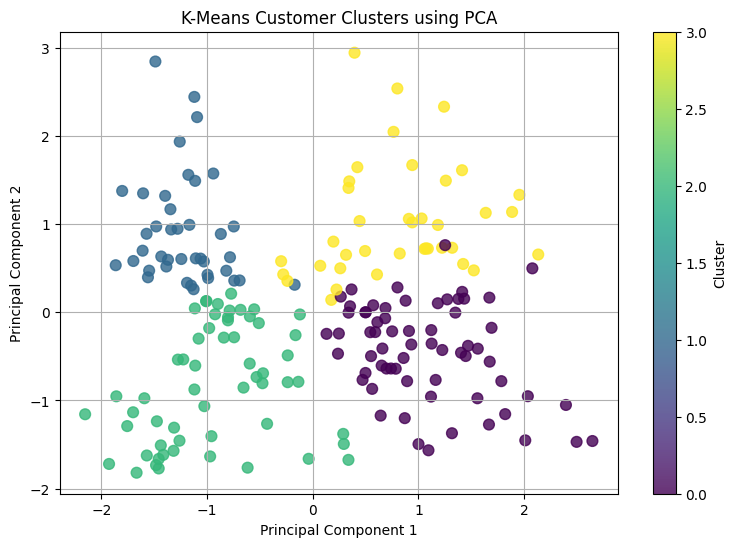

In [15]:
# Visualize K-Means clusters
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    s=60,
    alpha=0.8
)

plt.title('K-Means Customer Clusters using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')

plt.grid(True)
plt.show()

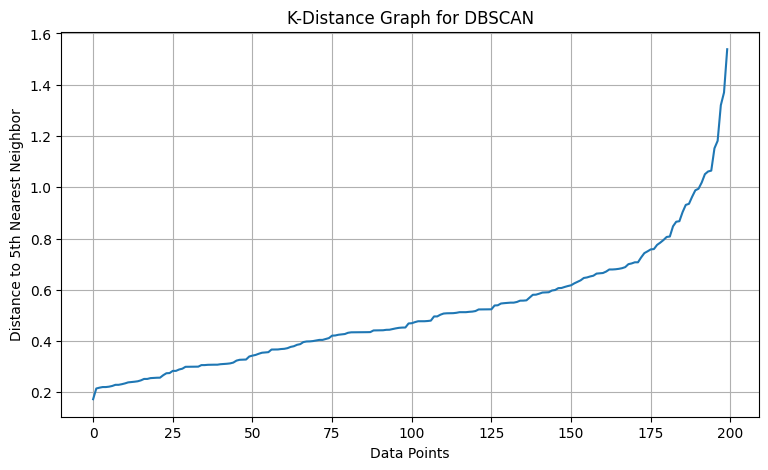

In [16]:
from sklearn.neighbors import NearestNeighbors

#distances to the 5th nearest neighbor
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])

# k-distance graph
plt.figure(figsize=(9, 5))
plt.plot(distances)

plt.title('K-Distance Graph for DBSCAN')
plt.xlabel('Data Points')
plt.ylabel('Distance to 5th Nearest Neighbor')
plt.grid(True)
plt.show()

In [17]:
# DBSCAN clustering

dbscan = DBSCAN(eps=0.75, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

print("DBSCAN Cluster Distribution:")
print(df['DBSCAN_Cluster'].value_counts().sort_index())

DBSCAN Cluster Distribution:
DBSCAN_Cluster
-1     10
 0    190
Name: count, dtype: int64


In [18]:
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:
    silhouette_dbscan = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )
    print("DBSCAN Silhouette Score:", silhouette_dbscan)
else:
    print("Silhouette Score cannot be calculated because fewer than 2 clusters were found.")

Silhouette Score cannot be calculated because fewer than 2 clusters were found.


In [19]:
eps_values = [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]

for eps in eps_values:
    dbscan_test = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan_test.fit_predict(X_scaled)

    mask = labels != -1
    n_clusters = len(set(labels[mask]))

    if n_clusters >= 2:
        score = silhouette_score(X_scaled[mask], labels[mask])
        print(f"eps={eps}: clusters={n_clusters}, noise={sum(labels == -1)}, silhouette={score:.3f}")
    else:
        print(f"eps={eps}: clusters={n_clusters}, noise={sum(labels == -1)}, silhouette=N/A")

eps=0.4: clusters=6, noise=98, silhouette=0.519
eps=0.45: clusters=5, noise=75, silhouette=0.542
eps=0.5: clusters=6, noise=60, silhouette=0.482
eps=0.55: clusters=4, noise=39, silhouette=0.234
eps=0.6: clusters=2, noise=28, silhouette=0.273
eps=0.65: clusters=2, noise=21, silhouette=0.265
eps=0.7: clusters=1, noise=14, silhouette=N/A


In [20]:
# Final DBSCAN model

dbscan = DBSCAN(eps=0.45, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

print("DBSCAN Cluster Distribution:")
print(df['DBSCAN_Cluster'].value_counts().sort_index())

DBSCAN Cluster Distribution:
DBSCAN_Cluster
-1    75
 0    14
 1    47
 2    27
 3    31
 4     6
Name: count, dtype: int64


In [21]:
mask = dbscan_labels != -1

silhouette_dbscan = silhouette_score(
    X_scaled[mask],
    dbscan_labels[mask]
)

print("DBSCAN Silhouette Score:", silhouette_dbscan)
print("Number of noise points:", sum(dbscan_labels == -1))

DBSCAN Silhouette Score: 0.5422780428534556
Number of noise points: 75


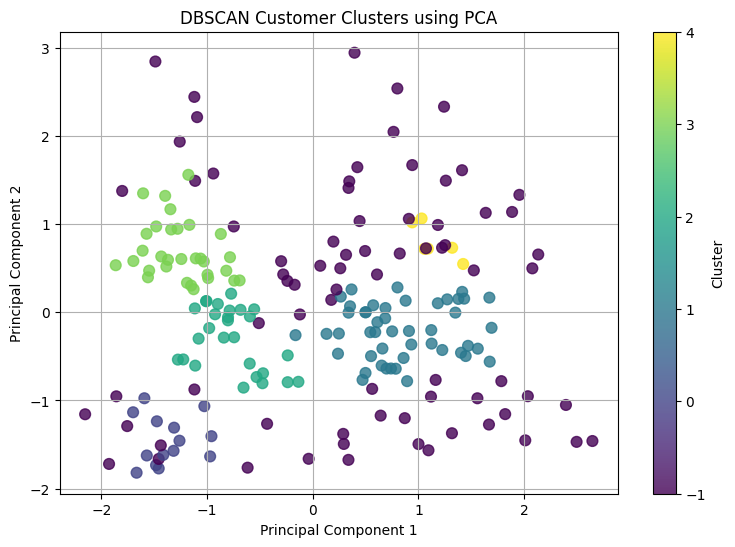

In [22]:
# Visualize DBSCAN clusters

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    cmap='viridis',
    s=60,
    alpha=0.8
)

plt.title('DBSCAN Customer Clusters using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')

plt.grid(True)
plt.show()

In [23]:
kmeans_summary = df.groupby('KMeans_Cluster')[features].mean().round(2)

kmeans_summary

,Age,Annual Income (k$),Spending Score (1-100)
KMeans_Cluster,,,
0,53.98,47.71,39.97
1,32.88,86.10,81.53
2,25.44,40.00,60.30
3,39.37,86.50,19.58


In [24]:
cluster_sizes = df['KMeans_Cluster'].value_counts().sort_index()

print("Customers in each cluster:")
print(cluster_sizes)

Customers in each cluster:
KMeans_Cluster
0    65
1    40
2    57
3    38
Name: count, dtype: int64


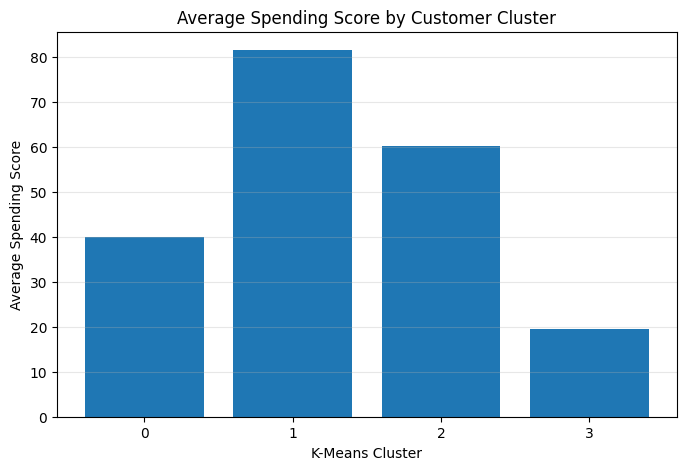

In [25]:
# Visualize average spending score by K-Means cluster

plt.figure(figsize=(8, 5))

plt.bar(
    kmeans_summary.index.astype(str),
    kmeans_summary['Spending Score (1-100)']
)

plt.title('Average Spending Score by Customer Cluster')
plt.xlabel('K-Means Cluster')
plt.ylabel('Average Spending Score')
plt.grid(axis='y', alpha=0.3)

plt.show()

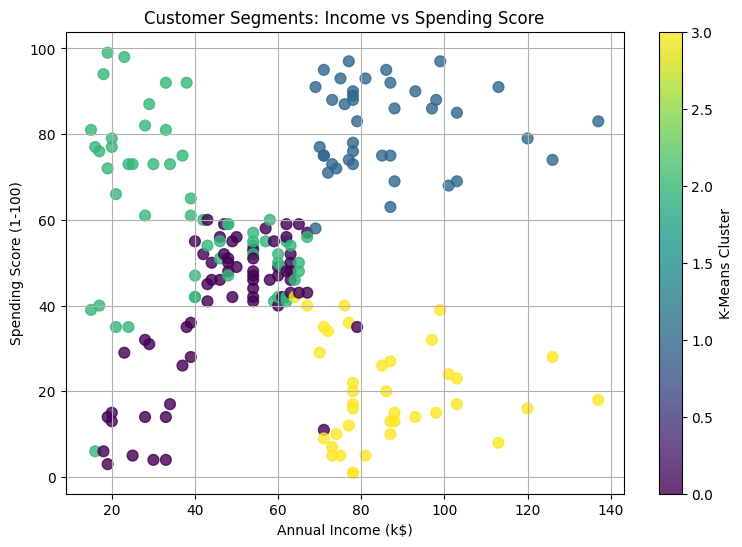

In [26]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['KMeans_Cluster'],
    cmap='viridis',
    s=60,
    alpha=0.8
)

plt.title('Customer Segments: Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.colorbar(label='K-Means Cluster')

plt.grid(True)
plt.show()

In [27]:
# Compare K-Means and DBSCAN

comparison = pd.DataFrame({
    'Algorithm': ['K-Means', 'DBSCAN'],
    'Number of Clusters': [4, 5],
    'Silhouette Score': [silhouette_kmeans, silhouette_dbscan],
    'Noise Points': [0, sum(dbscan_labels == -1)]
})

comparison

,Algorithm,Number of Clusters,Silhouette Score,Noise Points
0,K-Means,4,0.403958,0
1,DBSCAN,5,0.542278,75


In [28]:
print("Clustering Algorithm Comparison")
print("-" * 40)

print(f"K-Means:")
print(f"  Clusters: 4")
print(f"  Silhouette Score: {silhouette_kmeans:.3f}")
print(f"  Noise Points: 0")

print(f"\nDBSCAN:")
print(f"  Clusters: 5")
print(f"  Silhouette Score: {silhouette_dbscan:.3f}")
print(f"  Noise Points: {sum(dbscan_labels == -1)}")

Clustering Algorithm Comparison
----------------------------------------
K-Means:
  Clusters: 4
  Silhouette Score: 0.404
  Noise Points: 0

DBSCAN:
  Clusters: 5
  Silhouette Score: 0.542
  Noise Points: 75


In [29]:
cluster_profile = kmeans_summary.copy()

cluster_profile['Customer Count'] = cluster_sizes

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Customer Count
KMeans_Cluster,,,,
0,53.98,47.71,39.97,65
1,32.88,86.10,81.53,40
2,25.44,40.00,60.30,57
3,39.37,86.50,19.58,38


In [30]:

cluster_names = {
    0: 'Older Moderate-Spending',
    1: 'High-Value Customers',
    2: 'Young High-Spenders',
    3: 'High-Income Low-Spenders'
}

cluster_profile['Segment'] = cluster_profile.index.map(cluster_names)

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Customer Count,Segment
KMeans_Cluster,,,,,
0,53.98,47.71,39.97,65,Older Moderate-Spending
1,32.88,86.10,81.53,40,High-Value Customers
2,25.44,40.00,60.30,57,Young High-Spenders
3,39.37,86.50,19.58,38,High-Income Low-Spenders


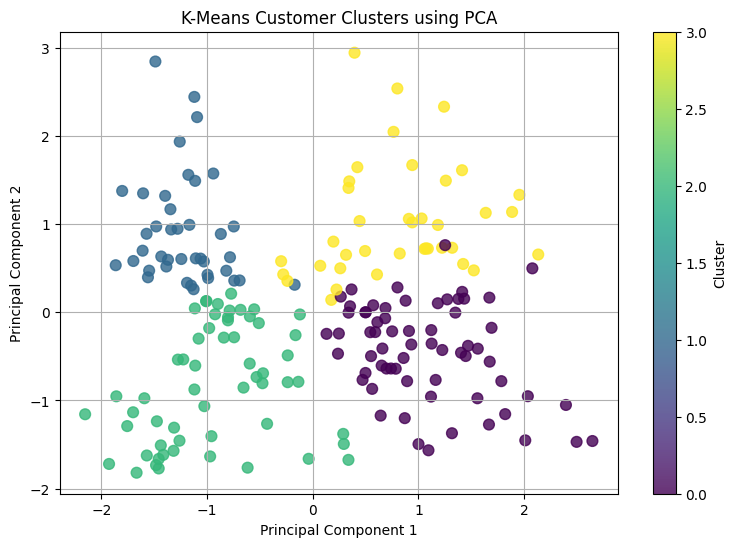

In [31]:
# Saving K-Means PCA visualization as PNG

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    s=60,
    alpha=0.8
)

plt.title('K-Means Customer Clusters using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.grid(True)

plt.savefig('kmeans_clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()

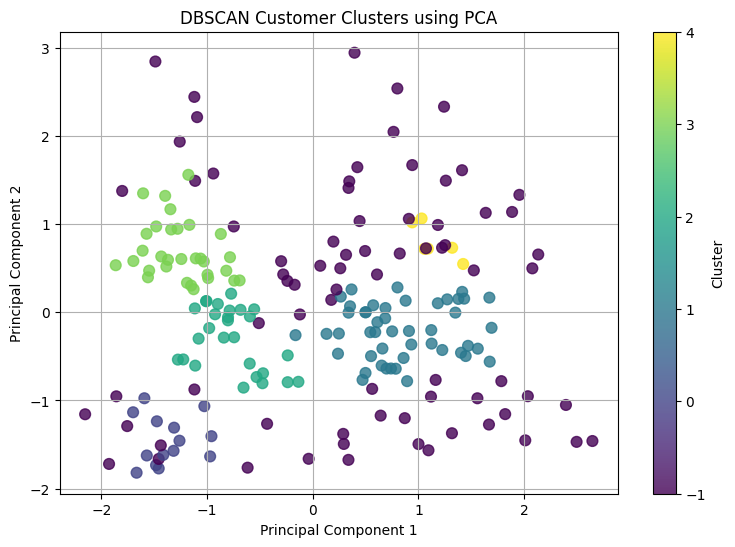

In [32]:
# Savin DBSCAN PCA visualization as PNG

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    cmap='viridis',
    s=60,
    alpha=0.8
)

plt.title('DBSCAN Customer Clusters using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.grid(True)

plt.savefig('dbscan_clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
import os

print(os.path.exists('kmeans_clusters_pca.png'))
print(os.path.exists('dbscan_clusters_pca.png'))

True
True


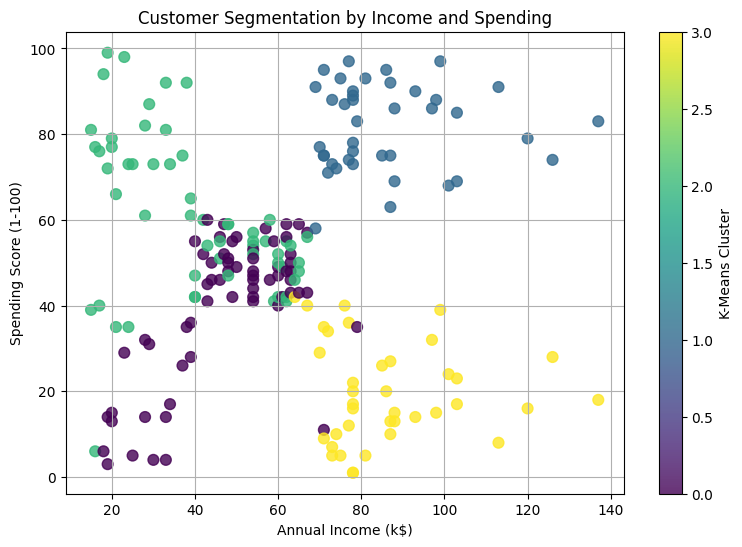

In [34]:
#Saving Income vs spending cluster visulization
plt.figure(figsize=(9, 6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['KMeans_Cluster'],
    cmap='viridis',
    s=60,
    alpha=0.8
)

plt.title('Customer Segmentation by Income and Spending')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.colorbar(label='K-Means Cluster')
plt.grid(True)

plt.savefig('customer_segmentation_income_spending.png',
            dpi=300, bbox_inches='tight')

plt.show()

# **Use Case Suggestion: Customer Segmentation**

**Purpose:**
Clustering can be used to divide customers into groups with similar characteristics. This helps a company understand different types of customers and provide better services.

**How it works:**
The clustering model analyzes customer features such as tenure, monthly charges, total spending, and number of subscribed services. Customers with similar behavior are grouped into the same cluster.

**Example Customer Groups:**

* **High-value customers:** High monthly charges and many subscribed services.
* **Loyal customers:** Long tenure and stable service usage.
* **Low-usage customers:** Fewer services and lower monthly spending.
* **Potential churn customers:** Customers with patterns that may indicate a risk of leaving.

**Business Benefits:**

* Helps create targeted marketing campaigns.
* Improves customer retention.
* Allows personalized offers for different customer groups.
* Helps identify valuable customer segments.
* Supports better business decision-making.

**Conclusion:**
Customer segmentation helps businesses create targeted marketing campaigns, improve customer retention, and provide personalized offers. It also helps identify valuable customers and supports better business decisions.

Overall, clustering is a useful real-world application of unsupervised learning because it automatically discovers groups of customers with similar behavior. This allows businesses to better understand their customers and develop more effective strategies.
